# Task 1
## Task 1.1

**Estado elegido: Delaware (`DE`, FIPS `10`).** El extracto vial completo del estado pudo obtenerse y procesarse
localmente. Delaware tiene 13 hospitales con datos de camas y 3 condados. Esta selección permite comparar los
buffers con isocronas sobre toda la red vial estatal, aunque el número reducido de condados limita los rankings
solicitados en los Tasks 1 y 2.

### a. Carga de los cuatro archivos
Las dependencias están en `requirements.txt`. Para instalarlas en un entorno virtual:

```bash
python -m venv .venv
.venv\Scriptsctivate
pip install -r requirements.txt
```


In [1]:
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import shapely
import pyproj
from scipy import stats
from scipy.spatial import cKDTree
from matplotlib_scalebar.scalebar import ScaleBar

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 100)

print("geopandas :", gpd.__version__)
print("shapely   :", shapely.__version__)
print("pandas    :", pd.__version__)
print("numpy     :", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("pyproj    :", pyproj.__version__)

geopandas : 1.1.4
shapely   : 2.1.2
pandas    : 2.3.3
numpy     : 2.4.6
matplotlib: 3.11.1
pyproj    : 3.7.2


In [2]:
# Parámetros globales
STATE = "DE"
STATE_FIPS = "10"
STATE_NAME = "Delaware"
CRS_PROJ = "EPSG:26957"
RADII_KM = [10, 25, 50]
R_MAP = 25

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
NEUTRAL = "#f0efec"
TIPO_ES = {"GENERAL ACUTE CARE": "Cuidados agudos generales", "CRITICAL ACCESS": "Acceso crítico",
           "PSYCHIATRIC": "Psiquiátrico", "LONG TERM CARE": "Cuidados a largo plazo",
           "REHABILITATION": "Rehabilitación", "MILITARY": "Militar", "CHILDREN": "Infantil",
           "SPECIAL": "Especial", "WOMEN": "Mujeres", "CHRONIC DISEASE": "Enfermedad crónica", "OTHER": "Otro"}


def add_north_and_scale(ax, loc="lower left"):
    # Escala gráfica y flecha de norte
    ax.add_artist(ScaleBar(1, units="m", location=loc, box_alpha=0.8, length_fraction=0.25))
    ax.annotate("N", xy=(0.95, 0.95), xytext=(0.95, 0.85), xycoords="axes fraction",
                ha="center", va="center", fontsize=14, fontweight="bold",
                arrowprops=dict(facecolor="black", width=4, headwidth=12))


In [3]:
hosp_raw = gpd.read_file("hospitales_eeuu.geojson")
counties_raw = gpd.read_file("condados_eeuu.geojson")
states = gpd.read_file("estados_eeuu.geojson")
pop_raw = pd.read_csv("poblacion_condados.csv")

resumen = pd.DataFrame([
    {"archivo": name, "registros": len(df), "CRS": str(df.crs) if isinstance(df, gpd.GeoDataFrame) else "— (tabla)",
     "columnas": ", ".join(df.columns)}
    for name, df in [("hospitales_eeuu.geojson", hosp_raw), ("condados_eeuu.geojson", counties_raw),
                     ("poblacion_condados.csv", pop_raw), ("estados_eeuu.geojson", states)]])
with pd.option_context("display.max_colwidth", 200):
    display(resumen)

,archivo,registros,CRS,columnas
0,hospitales_eeuu.geojson,7154,EPSG:4326,"nombre, tipo, ciudad, estado, condado, fips_condado, camas_total, camas_icu, camas_licenciadas, ocupacion_total, ocupacion_icu, geometry"
1,condados_eeuu.geojson,3221,EPSG:4326,"fips, nombre, cod_estado, geometry"
2,poblacion_condados.csv,3246,— (tabla),"fips, condado, estado, lat, lon, poblacion"
3,estados_eeuu.geojson,51,EPSG:4326,"nombre, codigo, pais, geometry"


### b. Limpieza del dataset completo

1. **Población:** los FIPS ≥ 80000 son registros “Out of XX” (personas reportadas fuera de su condado de
   residencia), no condados reales; se eliminan. Luego `fips` se convierte a texto de 5 dígitos con ceros a la
   izquierda (`1001` → `"01001"`) para que sea compatible con `condados_eeuu.geojson`.
2. **Hospitales:** se reporta el porcentaje de `camas_total` nulo y se conservan solo los hospitales con camas.

In [4]:
n_fake = (pop_raw["fips"] >= 80000).sum()
pop = pop_raw[pop_raw["fips"] < 80000].copy()
pop["fips"] = pop["fips"].astype(int).astype(str).str.zfill(5)
print(f"Población: {len(pop_raw)} registros -> {len(pop)} (eliminados {n_fake} con FIPS >= 80000)")
print(f"  ¿Todos los FIPS tienen 5 dígitos? {pop['fips'].str.len().eq(5).all()} | ejemplo: {pop['fips'].iloc[0]}")
print(f"  Población nula restante: {pop['poblacion'].isna().sum()}")

pct_null = 100 * hosp_raw["camas_total"].isna().mean()
pct_null_st = 100 * hosp_raw.loc[hosp_raw["estado"] == STATE, "camas_total"].isna().mean()
hosp = hosp_raw[hosp_raw["camas_total"].notna()].copy()
print(f"\nHospitales con camas_total nulo: {hosp_raw['camas_total'].isna().sum()} de {len(hosp_raw)} "
      f"= {pct_null:.2f} % (en {STATE_NAME}: {pct_null_st:.2f} %)")
print(f"Hospitales con datos de camas (EE.UU.): {len(hosp)}")
print(f"Hospitales en {STATE_NAME}: {(hosp_raw.estado == STATE).sum()} antes -> {(hosp.estado == STATE).sum()} "
      "después de la limpieza")

Población: 3246 registros -> 3144 (eliminados 102 con FIPS >= 80000)
  ¿Todos los FIPS tienen 5 dígitos? True | ejemplo: 01001
  Población nula restante: 0

Hospitales con camas_total nulo: 1090 de 7154 = 15.24 % (en Delaware: 13.33 %)
Hospitales con datos de camas (EE.UU.): 6064
Hospitales en Delaware: 15 antes -> 13 después de la limpieza


### c. Filtro por estado y unión población–geometría

In [5]:
hosp_st = hosp[hosp["estado"] == STATE].reset_index(drop=True)
cty_geo = counties_raw[counties_raw["cod_estado"] == STATE_FIPS]
pop_st = pop[pop["fips"].str[:2] == STATE_FIPS]
state_geo = states[states["codigo"] == STATE]

# unión 1:1 por la llave FIPS
cty = cty_geo.merge(pop_st[["fips", "poblacion"]], on="fips", how="left", validate="1:1").reset_index(drop=True)
print(f"Condados con geometría : {len(cty_geo)}")
print(f"Condados con población : {len(pop_st)}")
print(f"Condados unidos        : {cty['poblacion'].notna().sum()}  -> ¿coinciden? "
      f"{len(cty_geo) == len(pop_st) == cty['poblacion'].notna().sum()}")
print(f"Población total de {STATE_NAME}: {cty['poblacion'].sum():,.0f}")

# verificación espacial: ¿todos los hospitales caen dentro del límite estatal?
inside_state = hosp_st.within(state_geo.geometry.iloc[0])
print(f"\nHospitales del estado: {len(hosp_st)} | dentro del polígono estatal: {inside_state.sum()}")
print(hosp_st["tipo"].value_counts().rename(index=TIPO_ES).to_string())

Condados con geometría : 3
Condados con población : 3
Condados unidos        : 3  -> ¿coinciden? True
Población total de Delaware: 973,764

Hospitales del estado: 13 | dentro del polígono estatal: 13
tipo
Cuidados agudos generales    7
Psiquiátrico                 4
Cuidados a largo plazo       1
Rehabilitación               1


### d. Reproyección y justificación del CRS

**CRS elegido: EPSG:26957, NAD83 / Delaware.**

Es el sistema State Plane diseñado específicamente para Delaware, usa metros y mantiene una distorsión de escala
muy pequeña dentro del estado. Por ello es apropiado para distancias, buffers y áreas locales. Se compara con UTM
18N, Web Mercator y Albers para verificar cuantitativamente la elección.


In [6]:
cty_p0 = cty.to_crs(CRS_PROJ)
gx, gy = np.meshgrid(np.linspace(*cty_p0.total_bounds[[0, 2]], 60), np.linspace(*cty_p0.total_bounds[[1, 3]], 60))
grid_pts = gpd.GeoSeries(gpd.points_from_xy(gx.ravel(), gy.ravel()), crs=CRS_PROJ)
grid_pts = grid_pts[grid_pts.within(cty_p0.union_all())].to_crs("EPSG:4326")
cent_ll = cty_p0.geometry.centroid.to_crs("EPSG:4326")

rows = []
for epsg, desc in [(26957, "State Plane Delaware"), (32618, "UTM 18N (WGS84)"),
                   (3857, "Web Mercator"), (5070, "Albers EE.UU. contiguo")]:
    proj = pyproj.Proj(f"EPSG:{epsg}")

    def err(lon, lat):
        factors = proj.get_factors(lon, lat)
        return 100 * np.maximum(np.abs(factors.meridional_scale - 1),
                                np.abs(factors.parallel_scale - 1))

    rows.append({"CRS": f"EPSG:{epsg}", "descripción": desc,
                 "error escala máx (%)": err(grid_pts.x.values, grid_pts.y.values).max(),
                 "error medio ponderado por población (%)": np.average(
                     err(cent_ll.x.values, cent_ll.y.values), weights=cty["poblacion"])})
pd.DataFrame(rows).set_index("CRS")


,descripción,error escala máx (%),error medio ponderado por población (%)
CRS,,,
EPSG:26957,State Plane Delaware,0.00,0.00
EPSG:32618,UTM 18N (WGS84),0.04,0.04
EPSG:3857,Web Mercator,30.19,29.17
EPSG:5070,Albers EE.UU. contiguo,0.97,0.95


In [7]:
hosp_p = hosp_st.to_crs(CRS_PROJ)
cty_p = cty.to_crs(CRS_PROJ)
state_p = state_geo.to_crs(CRS_PROJ)
state_poly = state_p.geometry.iloc[0]
for name, g in [("hospitales", hosp_p), ("condados", cty_p), ("estado", state_p)]:
    print(f"{name:<11} -> {g.crs}")
cty_p["area_km2"] = cty_p.area / 1e6
print(f"Área total de los condados: {cty_p['area_km2'].sum():,.0f} km²")

hospitales  -> EPSG:26957
condados    -> EPSG:26957
estado      -> EPSG:26957
Área total de los condados: 5,245 km²


### e. Mapa base de tres capas

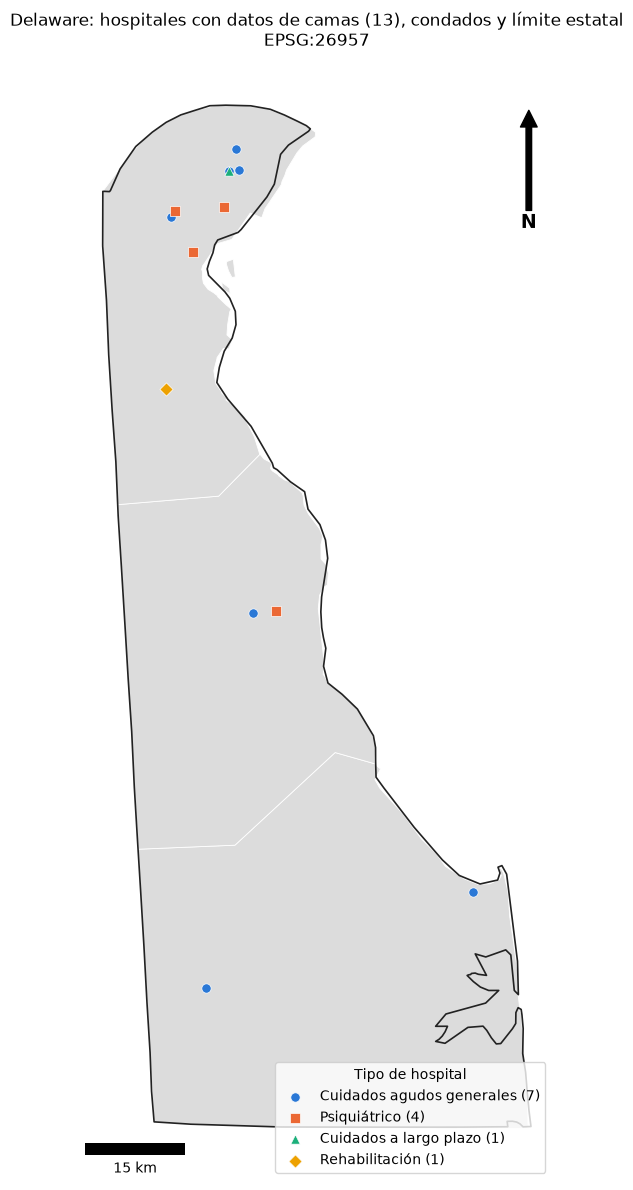

In [8]:
tipos_orden = hosp_p["tipo"].value_counts().index.tolist()
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
fig, ax = plt.subplots(figsize=(10, 12))
cty_p.plot(ax=ax, color="#dcdcdc", edgecolor="white", linewidth=0.6)
for i, t in enumerate(tipos_orden):
    sub = hosp_p[hosp_p["tipo"] == t]
    sub.plot(ax=ax, color=CAT[i], marker=markers[i], markersize=45, edgecolor="white", linewidth=0.5,
             label=f"{TIPO_ES.get(t, t)} ({len(sub)})", zorder=3)
state_p.boundary.plot(ax=ax, color="#222222", linewidth=1.2, zorder=4)
ax.legend(title="Tipo de hospital", loc="lower right", frameon=True)
add_north_and_scale(ax)
ax.set_title(f"{STATE_NAME}: hospitales con datos de camas ({len(hosp_p)}), condados y límite estatal\n"
             f"{CRS_PROJ}", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Task 1.2

Estadísticas por condado $k$ (hospitales asignados por intersección espacial punto-en-polígono):
* $n_k$ hospitales, $B_k = \sum_{j\in k}$ camas totales, $B^{UCI}_k = \sum_{j\in k}$ camas UCI (UCI nula → 0),
  $P_k$ población.
* Camas por 10,000 hab.: $b_k = 10^4\,B_k / P_k$; camas UCI por 10,000 hab.: $b^{UCI}_k = 10^4\,B^{UCI}_k / P_k$.
* Condados sin hospitales: 0 en todas las columnas numéricas.

In [9]:
hj = gpd.sjoin(hosp_p, cty_p[["fips", "geometry"]], how="left", predicate="within")
print(f"Hospitales asignados a un condado: {hj['fips'].notna().sum()} de {len(hj)} | "
      f"coinciden con la columna fips_condado: {(hj['fips'] == hj['fips_condado']).mean():.1%}")

agg = hj.groupby("fips").agg(hospitales=("nombre", "size"), camas_total=("camas_total", "sum"),
                             camas_uci=("camas_icu", lambda s: s.fillna(0).sum()))
stats_cty = cty_p[["fips", "nombre", "poblacion", "area_km2"]].merge(agg, on="fips", how="left")
stats_cty[["hospitales", "camas_total", "camas_uci"]] = stats_cty[["hospitales", "camas_total", "camas_uci"]].fillna(0)
stats_cty["hospitales"] = stats_cty["hospitales"].astype(int)
stats_cty["camas_10k"] = 1e4 * stats_cty["camas_total"] / stats_cty["poblacion"]
stats_cty["uci_10k"] = 1e4 * stats_cty["camas_uci"] / stats_cty["poblacion"]
tabla_12 = stats_cty.drop(columns="area_km2").sort_values("nombre").reset_index(drop=True)
tabla_12.index += 1
print(f"Condados sin hospital: {(stats_cty.hospitales == 0).sum()} de {len(stats_cty)}")
tabla_12

Hospitales asignados a un condado: 13 de 13 | coinciden con la columna fips_condado: 100.0%
Condados sin hospital: 0 de 3


,fips,nombre,poblacion,hospitales,camas_total,camas_uci,camas_10k,uci_10k
1,10001,Kent,"180,786.00",2,380.00,29.00,21.02,1.60
2,10003,New Castle,"558,753.00",9,"2,812.00",201.00,50.33,3.60
3,10005,Sussex,"234,225.00",2,289.00,29.00,12.34,1.24


### a. Cinco condados con menos camas por habitante (población > 10,000)
Varios condados tienen 0 camas; en caso de empate se ordena por población descendente (más personas sin camas
locales = mayor vulnerabilidad).

In [10]:
big = stats_cty[stats_cty["poblacion"] > 10_000]
print(f"Condados con > 10,000 hab.: {len(big)} | de ellos con 0 camas: {(big.camas_total == 0).sum()}")
low5 = big.sort_values(["camas_10k", "poblacion"], ascending=[True, False]).head(5).reset_index(drop=True)
low5.index += 1
low5[["nombre", "poblacion", "hospitales", "camas_total", "camas_uci", "camas_10k", "uci_10k"]]

Condados con > 10,000 hab.: 3 | de ellos con 0 camas: 0


,nombre,poblacion,hospitales,camas_total,camas_uci,camas_10k,uci_10k
1,Sussex,"234,225.00",2,289.00,29.00,12.34,1.24
2,Kent,"180,786.00",2,380.00,29.00,21.02,1.60
3,New Castle,"558,753.00",9,"2,812.00",201.00,50.33,3.60


### b. Cinco condados con mayor concentración de camas
Para evaluar si la concentración es un efecto de **hospitales regionales**, se recalcula la razón de camas
incluyendo la población de los condados vecinos (que comparten frontera):
$b^{reg}_k = 10^4 \,(B_k + \sum_{l \in V(k)} B_l) / (P_k + \sum_{l\in V(k)} P_l)$.

In [11]:
top5c = stats_cty.sort_values("camas_10k", ascending=False).head(5).copy()
geo_idx = cty_p.set_index("fips").geometry
rows = []
for _, r in top5c.iterrows():
    neigh = cty_p[cty_p.geometry.touches(geo_idx[r.fips])]["fips"]
    nb = stats_cty[stats_cty["fips"].isin(neigh)]
    big_h = hosp_p[hosp_p["fips_condado"] == r.fips].sort_values("camas_total", ascending=False).iloc[0]
    rows.append({"condado": r.nombre, "poblacion": r.poblacion, "camas_total": r.camas_total,
                 "camas_10k": r.camas_10k, "vecinos": len(nb), "vecinos_sin_hospital": int((nb.hospitales == 0).sum()),
                 "camas_10k_vecinos": 1e4 * nb.camas_total.sum() / nb.poblacion.sum(),
                 "camas_10k_regional": 1e4 * (r.camas_total + nb.camas_total.sum()) / (r.poblacion + nb.poblacion.sum()),
                 "hospital_principal": f"{big_h.nombre.title()} ({big_h.camas_total:.0f} camas)"})
top5_tbl = pd.DataFrame(rows)
top5_tbl.index += 1
print(f"Promedio estatal: {1e4 * stats_cty.camas_total.sum() / stats_cty.poblacion.sum():.1f} camas por 10,000 hab.")
with pd.option_context("display.max_colwidth", 60):
    display(top5_tbl)

Promedio estatal: 35.7 camas por 10,000 hab.


,condado,poblacion,camas_total,camas_10k,vecinos,vecinos_sin_hospital,camas_10k_vecinos,camas_10k_regional,hospital_principal
1,New Castle,"558,753.00","2,812.00",50.33,1,0,21.02,43.16,Christiana Care-Wilmington Hospital (1097 camas)
2,Kent,"180,786.00",380.00,21.02,2,0,39.11,35.75,Bayhealth Kent General Hospital (281 camas)
3,Sussex,"234,225.00",289.00,12.34,1,0,21.02,16.12,Beebe Medical Center (195 camas)


### c. Distribuciones: camas por hospital y camas por habitante por condado
Se reporta la asimetría muestral (coeficiente de Fisher–Pearson, $g_1 = m_3 / m_2^{3/2}$) y la comparación
media vs. mediana.

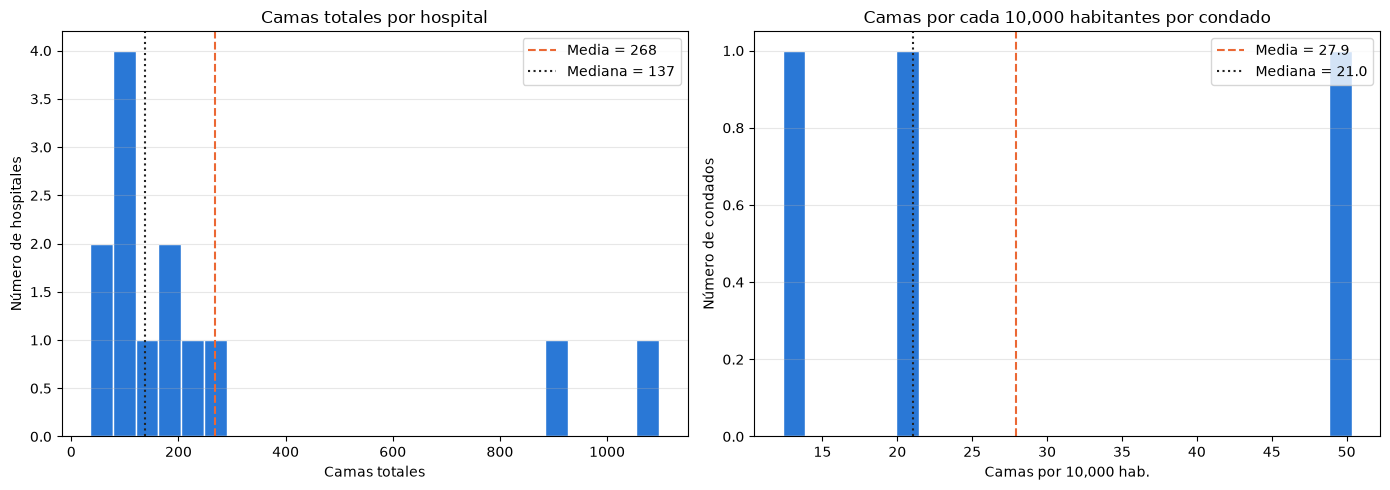

Condados con 0 camas: 0 de 3


,camas por hospital,camas por 10k hab. (condado)
n,13.00,3.00
media,267.77,27.89
mediana,137.00,21.02
mínimo,35.00,12.34
máximo,"1,097.00",50.33
asimetría g1,1.81,0.56
valores extremos (> Q3 + 1.5·IQR),2.00,0.00


In [12]:
camas_h = hosp_p["camas_total"]
camas_c = stats_cty["camas_10k"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.hist(camas_h, bins=25, color=CAT[0], edgecolor="white")
a1.axvline(camas_h.mean(), color=CAT[1], ls="--", lw=1.5, label=f"Media = {camas_h.mean():.0f}")
a1.axvline(camas_h.median(), color="#222222", ls=":", lw=1.5, label=f"Mediana = {camas_h.median():.0f}")
a1.set(title="Camas totales por hospital", xlabel="Camas totales", ylabel="Número de hospitales")
a1.legend()
a1.grid(alpha=0.3, axis="y")
a2.hist(camas_c, bins=25, color=CAT[0], edgecolor="white")
a2.axvline(camas_c.mean(), color=CAT[1], ls="--", lw=1.5, label=f"Media = {camas_c.mean():.1f}")
a2.axvline(camas_c.median(), color="#222222", ls=":", lw=1.5, label=f"Mediana = {camas_c.median():.1f}")
a2.set(title="Camas por cada 10,000 habitantes por condado", xlabel="Camas por 10,000 hab.",
       ylabel="Número de condados")
a2.legend()
a2.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

desc = pd.DataFrame({
    "camas por hospital": [len(camas_h), camas_h.mean(), camas_h.median(), camas_h.min(), camas_h.max(),
                           stats.skew(camas_h), (camas_h > camas_h.quantile(0.75) + 1.5 * stats.iqr(camas_h)).sum()],
    "camas por 10k hab. (condado)": [len(camas_c), camas_c.mean(), camas_c.median(), camas_c.min(), camas_c.max(),
                                    stats.skew(camas_c), (camas_c > camas_c.quantile(0.75) + 1.5 * stats.iqr(camas_c)).sum()]},
    index=["n", "media", "mediana", "mínimo", "máximo", "asimetría g1", "valores extremos (> Q3 + 1.5·IQR)"])
print(f"Condados con 0 camas: {(camas_c == 0).sum()} de {len(camas_c)}")
desc

## Task 1.3

### a. Buffers de 10, 25 y 50 km y unión

Para cada radio $r$: $C_r = \bigcup_j B_r(s_j)$, donde $B_r(s_j) = \{x : \lVert x - s_j \rVert \le r\}$ es el
buffer del hospital $j$. Se usa `unary_union` para eliminar el doble conteo donde los buffers se traslapan.

In [13]:
from shapely.ops import unary_union

coverage = {}
for r in RADII_KM:
    buffers = hosp_p.geometry.buffer(r * 1000, resolution=32)        # metros, porque el CRS es UTM
    coverage[r] = unary_union(buffers.values)
    a_in = coverage[r].intersection(state_poly).area / 1e6
    print(f"r = {r:>2} km: {len(buffers)} buffers -> 1 polígono ({coverage[r].geom_type}), área cubierta dentro "
          f"del estado = {a_in:,.0f} km² ({100 * a_in / (state_poly.area / 1e6):.1f} %)")

r = 10 km: 13 buffers -> 1 polígono (MultiPolygon), área cubierta dentro del estado = 1,703 km² (32.9 %)
r = 25 km: 13 buffers -> 1 polígono (MultiPolygon), área cubierta dentro del estado = 4,534 km² (87.7 %)
r = 50 km: 13 buffers -> 1 polígono (Polygon), área cubierta dentro del estado = 5,172 km² (100.0 %)


### b. Población cubierta por radio (supuesto de densidad uniforme)

Si la población del condado $k$ está distribuida uniformemente sobre su área $A_k$, la población cubierta es
proporcional al área cubierta:
$$P^{cub}_r = \sum_k P_k\,\frac{\lvert A_k \cap C_r\rvert}{\lvert A_k\rvert}, \qquad \text{Cob}(r) = \frac{P^{cub}_r}{\sum_k P_k}.$$

In [14]:
P_TOTAL = cty_p["poblacion"].sum()


def frac_covered(cov_geom):
    """Fracción del área de cada condado dentro del polígono de cobertura."""
    return (cty_p.geometry.intersection(cov_geom).area / cty_p.area).clip(0, 1).values


cov_rows = []
for r in RADII_KM:
    pc = (cty_p["poblacion"] * frac_covered(coverage[r])).sum()
    cov_rows.append({"radio_km": r, "poblacion_cubierta_estimada": pc, "poblacion_total": P_TOTAL,
                     "pct_cobertura": 100 * pc / P_TOTAL})
cov_tbl = pd.DataFrame(cov_rows)
cov_tbl

,radio_km,poblacion_cubierta_estimada,poblacion_total,pct_cobertura
0,10,"501,516.37","973,764.00",51.50
1,25,"909,144.09","973,764.00",93.36
2,50,"973,764.00","973,764.00",100.00


### c. Mapa de cobertura con radio de 25 km

Cada condado se clasifica según la fracción de su área dentro de $C_{25}$: completamente cubierto (≥ 99.5 %),
parcialmente cubierto, o no cubierto (< 0.5 %). Escala divergente rojo ↔ azul con gris neutro al centro: el rojo
resalta las zonas sin cobertura.

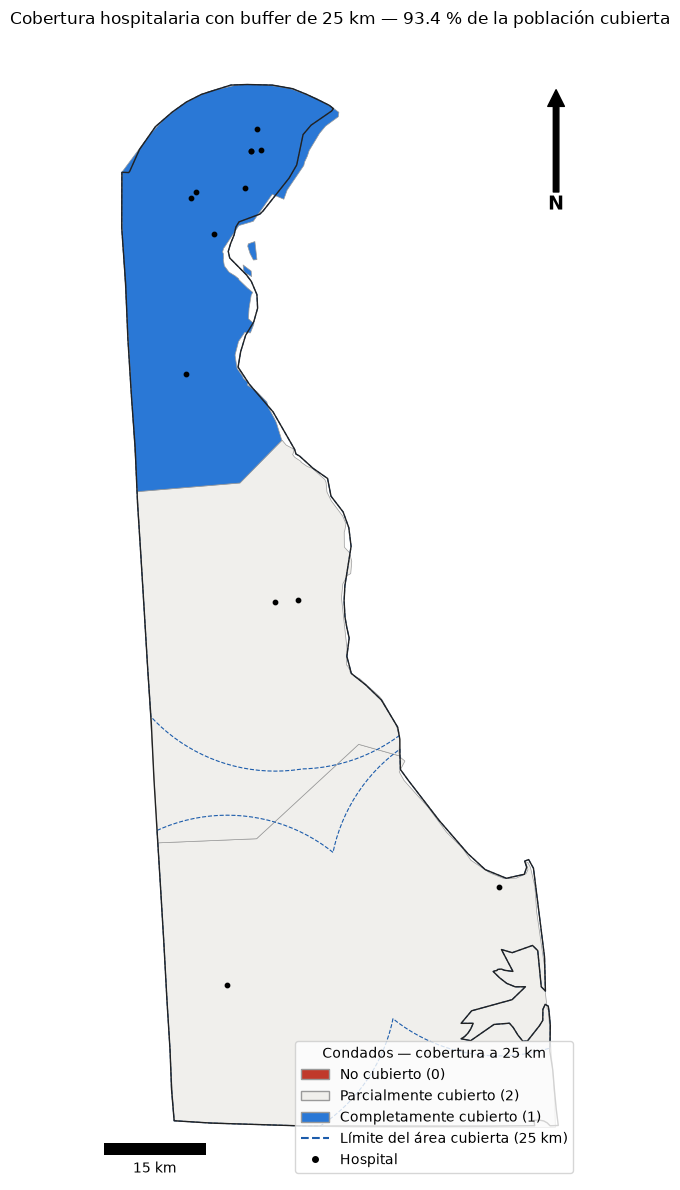

                        condados
cobertura25                     
Parcialmente cubierto          2
Completamente cubierto         1
No cubierto                    0

Condados NO cubiertos: ninguno


In [15]:
cov25 = coverage[R_MAP]
cty_p["frac_cub25"] = frac_covered(cov25)
cty_p["cobertura25"] = pd.cut(cty_p["frac_cub25"], [-0.01, 0.005, 0.995, 1.01],
                              labels=["No cubierto", "Parcialmente cubierto", "Completamente cubierto"])
DIV = {"No cubierto": "#c0392b", "Parcialmente cubierto": NEUTRAL, "Completamente cubierto": "#2a78d6"}

fig, ax = plt.subplots(figsize=(10, 12))
cty_p.plot(ax=ax, color=cty_p["cobertura25"].map(DIV).astype(str), edgecolor="#9a9a9a", linewidth=0.5)
gpd.GeoSeries([cov25.intersection(state_poly)], crs=CRS_PROJ).boundary.plot(ax=ax, color="#1c5cab",
                                                                             linewidth=0.8, linestyle="--")
hosp_p.plot(ax=ax, color="black", markersize=10, zorder=4)
state_p.boundary.plot(ax=ax, color="#222222", linewidth=1.0)
counts = cty_p["cobertura25"].value_counts()
handles = [Patch(facecolor=c, edgecolor="#9a9a9a", label=f"{k} ({counts.get(k, 0)})") for k, c in DIV.items()]
handles += [Line2D([], [], color="#1c5cab", ls="--", label=f"Límite del área cubierta ({R_MAP} km)"),
            Line2D([], [], marker="o", color="black", ls="", markersize=4, label="Hospital")]
ax.legend(handles=handles, loc="lower right", title=f"Condados — cobertura a {R_MAP} km")
add_north_and_scale(ax)
ax.set_title(f"Cobertura hospitalaria con buffer de {R_MAP} km — "
             f"{cov_tbl.loc[cov_tbl.radio_km == R_MAP, 'pct_cobertura'].item():.1f} % de la población cubierta")
ax.set_axis_off()
plt.tight_layout()
plt.show()
print(counts.to_frame("condados"))
print("\nCondados NO cubiertos:", ", ".join(cty_p.loc[cty_p.cobertura25 == "No cubierto", "nombre"]) or "ninguno")

# Task 2
## Task 2.1

### a. Distancia del centroide de cada condado al hospital más cercano
$d_k = \min_j \lVert c_k - s_j \rVert$, con $c_k$ el centroide del condado en el CRS proyectado (metros); el
mínimo se calcula con un árbol k-d.

In [16]:
hosp_xy = np.column_stack([hosp_p.geometry.x, hosp_p.geometry.y])
tree = cKDTree(hosp_xy)
cent = cty_p.geometry.centroid
d, j = tree.query(np.column_stack([cent.x, cent.y]))
cty_p["dist_km"] = d / 1000
cty_p["hosp_cercano"] = hosp_p["nombre"].str.title().values[j]
cty_p["tipo_cercano"] = hosp_p["tipo"].values[j]
cty_p["camas_cercano"] = hosp_p["camas_total"].values[j]

far10 = cty_p.sort_values("dist_km", ascending=False).head(10)
far10_tbl = far10[["nombre", "poblacion", "dist_km", "hosp_cercano"]].reset_index(drop=True)
far10_tbl.index += 1
print(f"Distancia media centroide–hospital: {cty_p.dist_km.mean():.1f} km (mediana {cty_p.dist_km.median():.1f} km)")
far10_tbl

Distancia media centroide–hospital: 11.2 km (mediana 8.2 km)


,nombre,poblacion,dist_km,hosp_cercano
1,Sussex,"234,225.00",18.81,Nanticoke Memorial Hospital
2,Kent,"180,786.00",8.16,Bayhealth Kent General Hospital
3,New Castle,"558,753.00",6.66,Meadow Wood Behavioral Health System


**Verificación del efecto de borde.** El enunciado restringe los hospitales al estado. Como referencia, sin usar
el resultado en el resto del análisis, se recalcula la distancia incluyendo hospitales con camas de todos los
estados. Esto permite detectar si un hospital de Maryland, Pennsylvania o New Jersey sería más cercano para algún
centroide de Delaware.


In [17]:
hosp_all_p = hosp.to_crs(CRS_PROJ)
d_all, j_all = cKDTree(np.column_stack([hosp_all_p.geometry.x, hosp_all_p.geometry.y])).query(
    np.column_stack([cent.x, cent.y]))
cty_p["dist_km_todos"] = d_all / 1000
cty_p["estado_cercano_todos"] = hosp_all_p["estado"].values[j_all]
borde = cty_p.loc[far10.index, ["nombre", "dist_km", "dist_km_todos", "estado_cercano_todos"]].reset_index(drop=True)
borde.index += 1
borde

,nombre,dist_km,dist_km_todos,estado_cercano_todos
1,Sussex,18.81,18.81,DE
2,Kent,8.16,8.16,DE
3,New Castle,6.66,6.66,DE


### b. Curva de cobertura acumulada (5–100 km)

$\text{Cob}(r) = \sum_k P_k\,\lvert A_k\cap C_r\rvert/\lvert A_k\rvert \,/\, P$ para $r = 5, 10, \dots, 100$ km.

**Punto de inflexión.** La curva es cóncava, así que el punto relevante es el *codo* (rendimientos
decrecientes). Se identifica con el método **Kneedle**: con ambos ejes normalizados a [0, 1], el codo maximiza
la distancia vertical entre la curva y la recta que une sus extremos, $r^{knee} = \arg\max_r[\tilde C(r) - \tilde r]$.
Como criterio complementario se reporta el primer radio en que la ganancia marginal cae bajo 1 p.p. por cada 5 km.

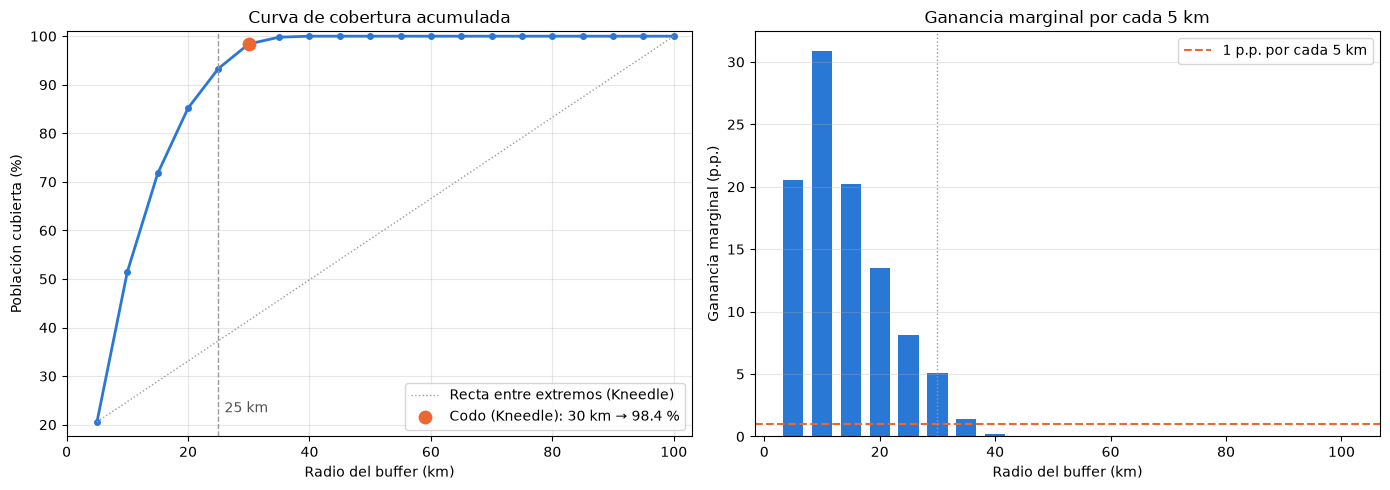

Codo (Kneedle): r = 30 km, cobertura = 98.4 %
Primer radio con ganancia < 1 p.p.: r = 40 km, cobertura = 100.0 %


radio_km,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100
pct_cobertura,20.60,51.50,71.70,85.20,93.30,98.40,99.80,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
ganancia_pp,20.60,30.90,20.30,13.50,8.20,5.10,1.40,0.20,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [18]:
radii = np.arange(5, 101, 5)
curve = np.array([100 * (cty_p["poblacion"] * frac_covered(unary_union(hosp_p.geometry.buffer(r * 1000).values))).sum()
                  / P_TOTAL for r in radii])
marg = np.diff(np.concatenate([[0], curve]))

xn = (radii - radii.min()) / (radii.max() - radii.min())
yn = (curve - curve.min()) / (curve.max() - curve.min())
r_knee = radii[np.argmax(yn - xn)]
c_knee = curve[radii == r_knee].item()
r_1pp = radii[np.argmax(marg < 1)]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.plot(radii, curve, color=CAT[0], lw=2, marker="o", markersize=4)
a1.plot([radii[0], radii[-1]], [curve[0], curve[-1]], color="#9a9a9a", lw=1, ls=":", label="Recta entre extremos (Kneedle)")
a1.scatter([r_knee], [c_knee], color=CAT[1], s=80, zorder=3, label=f"Codo (Kneedle): {r_knee} km → {c_knee:.1f} %")
a1.axvline(R_MAP, color="#9a9a9a", lw=1, ls="--")
a1.text(R_MAP + 1, curve.min() + 2, f"{R_MAP} km", color="#52514e")
a1.set(xlabel="Radio del buffer (km)", ylabel="Población cubierta (%)", title="Curva de cobertura acumulada",
       xlim=(0, 103), ylim=(curve.min() - 3, 101))
a1.grid(alpha=0.3)
a1.legend(loc="lower right")
a2.bar(radii, marg, color=CAT[0], width=3.5)
a2.axhline(1, color=CAT[1], lw=1.5, ls="--", label="1 p.p. por cada 5 km")
a2.axvline(r_knee, color="#9a9a9a", lw=1, ls=":")
a2.set(xlabel="Radio del buffer (km)", ylabel="Ganancia marginal (p.p.)", title="Ganancia marginal por cada 5 km")
a2.grid(alpha=0.3, axis="y")
a2.legend()
plt.tight_layout()
plt.show()

print(f"Codo (Kneedle): r = {r_knee} km, cobertura = {c_knee:.1f} %")
print(f"Primer radio con ganancia < 1 p.p.: r = {r_1pp} km, cobertura = {curve[radii == r_1pp].item():.1f} %")
pd.DataFrame({"radio_km": radii, "pct_cobertura": curve, "ganancia_pp": marg}).set_index("radio_km").T.round(1)

### c. Tipo y capacidad del hospital más cercano a los cinco condados más alejados
Para responder si los condados alejados quedan cerca de hospitales de menor capacidad, se compara con todos los
condados y se calcula la correlación de rangos de Spearman entre $d_k$ y las camas del hospital más cercano.

In [19]:
far5 = far10.head(5)
far5_tbl = far5[["nombre", "dist_km", "hosp_cercano", "tipo_cercano", "camas_cercano"]].reset_index(drop=True)
far5_tbl["tipo_cercano"] = far5_tbl["tipo_cercano"].map(TIPO_ES)
far5_tbl.index += 1
display(far5_tbl)

rho, pval = stats.spearmanr(cty_p["dist_km"], cty_p["camas_cercano"])
comp = pd.DataFrame({
    "5 condados más alejados": [far5.camas_cercano.median(), far5.camas_cercano.mean(), (far5.camas_cercano < 50).mean() * 100],
    "resto de condados": [cty_p.drop(far5.index).camas_cercano.median(), cty_p.drop(far5.index).camas_cercano.mean(),
                          (cty_p.drop(far5.index).camas_cercano < 50).mean() * 100],
    "todos los hospitales": [hosp_p.camas_total.median(), hosp_p.camas_total.mean(), (hosp_p.camas_total < 50).mean() * 100]},
    index=["mediana de camas", "media de camas", "% con < 50 camas"])
print(f"Correlación de Spearman (distancia vs camas del hospital más cercano): rho = {rho:.2f}, p = {pval:.3f}")
comp

,nombre,dist_km,hosp_cercano,tipo_cercano,camas_cercano
1,Sussex,18.81,Nanticoke Memorial Hospital,Cuidados agudos generales,94.00
2,Kent,8.16,Bayhealth Kent General Hospital,Cuidados agudos generales,281.00
3,New Castle,6.66,Meadow Wood Behavioral Health System,Psiquiátrico,97.00


Correlación de Spearman (distancia vs camas del hospital más cercano): rho = -0.50, p = 0.667


,5 condados más alejados,resto de condados,todos los hospitales
mediana de camas,97.00,NaN,137.00
media de camas,157.33,NaN,267.77
% con < 50 camas,0.00,NaN,15.38


## Task 2.2

| Componente | Variable cruda por condado $k$ | Dirección |
|---|---|---|
| $C_1$ distancia | $d_k$ — distancia del centroide al hospital más cercano (km) | más = más vulnerable |
| $C_2$ inverso de camas per cápita | $P_k / B_k$ — habitantes por cama; sin hospitales → máximo observado | más = más vulnerable |
| $C_3$ ocupación | $\bar o_k$ — ocupación promedio de los hospitales a ≤ 50 km del centroide; ninguno → máximo | más = más vulnerable |

### a. Normalización min-max
$\tilde x_k = \dfrac{x_k - \min_l x_l}{\max_l x_l - \min_l x_l} \in [0,1]$.

In [20]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())


vul = cty_p[["fips", "nombre", "poblacion", "geometry"]].merge(stats_cty[["fips", "camas_total", "hospitales"]], on="fips")
vul["x1_dist_km"] = cty_p["dist_km"].values

# C2: inverso de camas por habitante (habitantes por cama); condados sin camas -> valor máximo observado
inv = vul["poblacion"] / vul["camas_total"].replace(0, np.nan)
vul["x2_hab_por_cama"] = inv.fillna(inv.max())

# C3: ocupación promedio de hospitales dentro de 50 km del centroide; sin hospitales cercanos -> máximo
occ = hosp_p["ocupacion_total"].values
near50 = tree.query_ball_point(np.column_stack([cent.x, cent.y]), r=50_000)
occ_mean = np.array([np.nanmean(occ[m]) if len(m) and np.isfinite(occ[m]).any() else np.nan for m in near50])
vul["n_hosp_50km"] = [len(m) for m in near50]
vul["x3_ocupacion_50km"] = np.where(np.isnan(occ_mean), np.nanmax(occ_mean), occ_mean)

vul["C1"] = minmax(vul["x1_dist_km"])
vul["C2"] = minmax(vul["x2_hab_por_cama"])
vul["C3"] = minmax(vul["x3_ocupacion_50km"])
print(f"Condados sin camas (C2 = máximo): {(vul.camas_total == 0).sum()} | "
      f"sin hospitales a ≤ 50 km (C3 = máximo): {np.isnan(occ_mean).sum()}")
vul[["x1_dist_km", "x2_hab_por_cama", "x3_ocupacion_50km", "C1", "C2", "C3"]].describe().T[["mean", "50%", "min", "max"]]

Condados sin camas (C2 = máximo): 0 | sin hospitales a ≤ 50 km (C3 = máximo): 0


,mean,50%,min,max
x1_dist_km,11.21,8.16,6.66,18.81
x2_hab_por_cama,494.97,475.75,198.70,810.47
x3_ocupacion_50km,0.73,0.77,0.61,0.80
C1,0.37,0.12,0.00,1.00
C2,0.48,0.45,0.00,1.00
C3,0.60,0.81,0.00,1.00


### b. Pesos del índice

$V_k = w_1 C_{1,k} + w_2 C_{2,k} + w_3 C_{3,k}$, con $w_1 + w_2 + w_3 = 1$ (la justificación de cada peso está en el reporte).

In [21]:
WEIGHTS = {"C1": 0.45, "C2": 0.35, "C3": 0.20}
vul["V"] = sum(w * vul[c] for c, w in WEIGHTS.items())

LABELS = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
vul["V_cat"] = pd.qcut(vul["V"], 5, labels=LABELS)
top10 = vul.sort_values("V", ascending=False).head(10)
top10_tbl = top10[["nombre", "poblacion", "x1_dist_km", "x2_hab_por_cama", "x3_ocupacion_50km",
                   "C1", "C2", "C3", "V"]].reset_index(drop=True)
top10_tbl.index += 1
top10_tbl

,nombre,poblacion,x1_dist_km,x2_hab_por_cama,x3_ocupacion_50km,C1,C2,C3,V
1,Sussex,"234,225.00",18.81,810.47,0.61,1.00,1.00,0.00,0.80
2,Kent,"180,786.00",8.16,475.75,0.80,0.12,0.45,1.00,0.41
3,New Castle,"558,753.00",6.66,198.70,0.77,0.00,0.00,0.81,0.16


### c. Mapa coroplético por quintiles con los 10 condados más vulnerables

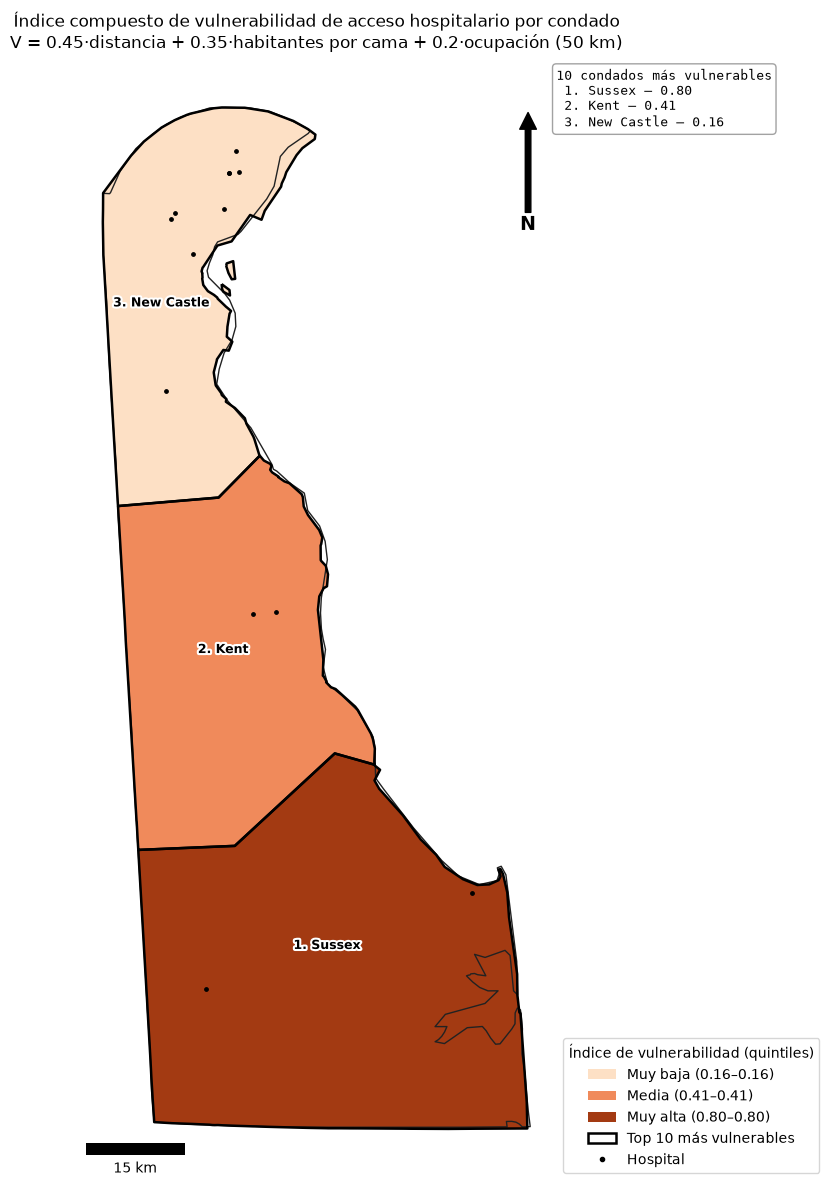

In [22]:
SEQ = ["#fde0c5", "#f8b58b", "#f08a5b", "#d95926", "#a33a12"]   # un solo tono (naranja), claro -> oscuro
fig, ax = plt.subplots(figsize=(11, 12))
vul.plot(ax=ax, color=vul["V_cat"].map(dict(zip(LABELS, SEQ))).astype(str), edgecolor="white", linewidth=0.6)
state_p.boundary.plot(ax=ax, color="#222222", linewidth=1.0)
top10.boundary.plot(ax=ax, color="black", linewidth=1.8)
hosp_p.plot(ax=ax, color="black", markersize=6, zorder=4)
names = []
for rank, (_, r) in enumerate(top10.iterrows(), start=1):
    pt = r.geometry.representative_point()
    ax.annotate(f"{rank}. {r.nombre}", xy=(pt.x, pt.y), fontsize=9, fontweight="bold", ha="center", va="center",
                path_effects=[pe.withStroke(linewidth=3, foreground="white")], zorder=5)
    names.append(f"{rank:>2}. {r.nombre} — {r.V:.2f}")
ax.text(1.01, 0.99, "10 condados más vulnerables\n" + "\n".join(names), transform=ax.transAxes,
        va="top", ha="left", fontsize=9, family="monospace",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#9a9a9a", alpha=0.92))
bins = vul.groupby("V_cat", observed=True)["V"].agg(["min", "max"])
handles = [Patch(facecolor=c, label=f"{l} ({bins.loc[l, 'min']:.2f}–{bins.loc[l, 'max']:.2f})")
           for l, c in zip(LABELS, SEQ) if l in bins.index]
handles += [Patch(facecolor="none", edgecolor="black", linewidth=1.8, label="Top 10 más vulnerables"),
            Line2D([], [], marker="o", color="black", ls="", markersize=3, label="Hospital")]
ax.legend(handles=handles, title="Índice de vulnerabilidad (quintiles)", loc="lower left", bbox_to_anchor=(1.01, 0))
add_north_and_scale(ax)
ax.set_title("Índice compuesto de vulnerabilidad de acceso hospitalario por condado\n"
             f"V = {WEIGHTS['C1']}·distancia + {WEIGHTS['C2']}·habitantes por cama + {WEIGHTS['C3']}·ocupación (50 km)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Task 2.3

**Formulación MCLP (Church & ReVelle, 1974)** adaptada a la cobertura existente:

$$\max \sum_{i} a_i\, y_i \quad \text{s.a.}\quad y_i \le \sum_{j \in N_i} x_j,\qquad \sum_j x_j = p,\qquad x_j, y_i \in \{0,1\}$$

donde la demanda $a_i$ es la población **sin cobertura actual** (densidad uniforme por condado), $j$ los puntos
candidatos, $N_i$ los candidatos a ≤ $S = 25$ km de la demanda $i$, y $p = 3$ nuevos hospitales.

### a. Grilla de candidatos (50 km)
Se generan puntos cada 50 km sobre la extensión del estado y se eliminan los que caen fuera del límite estatal
(intersección espacial con el polígono de `estados_eeuu.geojson`).

In [23]:
SPACING, S, P_NEW = 50_000, R_MAP * 1000, 3
minx, miny, maxx, maxy = state_poly.bounds
gx, gy = np.meshgrid(np.arange(minx + SPACING / 2, maxx, SPACING), np.arange(miny + SPACING / 2, maxy, SPACING))
grid = gpd.GeoDataFrame(geometry=gpd.points_from_xy(gx.ravel(), gy.ravel()), crs=CRS_PROJ)
cand = grid[grid.intersects(state_poly)].reset_index(drop=True)
print(f"Puntos de la grilla: {len(grid)} | fuera del estado: {len(grid) - len(cand)} | candidatos: {len(cand)}")

Puntos de la grilla: 3 | fuera del estado: 1 | candidatos: 2


### b. Población adicional por candidato
Con densidad uniforme $\rho_k = P_k / \lvert A_k\rvert$, la ganancia del candidato $j$ es la población de la parte
**no cubierta** de cada condado que cae dentro de su buffer:
$g_j = \sum_k \rho_k \,\lvert B_S(c_j) \cap (A_k \setminus C_{25})\rvert$.

In [24]:
dens = (cty_p["poblacion"] / cty_p.area).values               # hab/m²
cand_buf = cand.geometry.buffer(S, resolution=32)


def gains(cov_geom):
    """Población no cubierta (bajo cov_geom) dentro del buffer de cada candidato."""
    uncovered = cty_p.geometry.difference(cov_geom)          # A_k \ C
    out = np.zeros(len(cand))
    for i, b in enumerate(cand_buf):
        out[i] = (uncovered.intersection(b).area.values * dens).sum()
    return out


cand["pob_adicional"] = gains(cov25)
print(f"Candidatos con ganancia > 1,000 hab.: {(cand.pob_adicional > 1000).sum()} de {len(cand)}")
cand.sort_values("pob_adicional", ascending=False).head(10).assign(
    x=lambda d: d.geometry.x.round(), y=lambda d: d.geometry.y.round()).drop(columns="geometry")

Candidatos con ganancia > 1,000 hab.: 2 de 2


,pob_adicional,x,y
0,"17,217.62","193,082.00","75,339.00"
1,"7,208.78","193,082.00","125,339.00"


### c. Algoritmo voraz (p = 3)
En cada iteración: (1) elegir $j^* = \arg\max_j g_j$ con la cobertura vigente, (2) marcarlo como seleccionado,
(3) actualizar la cobertura $C \leftarrow C \cup B_S(c_{j^*})$, (4) recalcular $g_j$ y repetir.

In [25]:
cov_state = cov25
base_pct = 100 * (cty_p["poblacion"] * frac_covered(cov_state)).sum() / P_TOTAL
selected = []
for it in range(1, P_NEW + 1):
    g = gains(cov_state)
    g[[s["idx"] for s in selected]] = -1                       # no repetir candidatos
    j_best = int(np.argmax(g))
    cov_state = cov_state.union(cand_buf.iloc[j_best])         # actualizar el mapa de cobertura
    selected.append({"idx": j_best, "iteracion": it, "pob_adicional": g[j_best],
                     "pct_cobertura_acumulada": 100 * (cty_p["poblacion"] * frac_covered(cov_state)).sum() / P_TOTAL})

sel = cand.loc[[s["idx"] for s in selected]].copy()
sel = sel.assign(**pd.DataFrame(selected).set_index("idx"))
sel = gpd.sjoin(sel, cty_p[["nombre", "geometry"]], predicate="within", how="left").drop(columns="index_right")
sel_ll = sel.to_crs("EPSG:4326")
sel["lat"], sel["lon"] = sel_ll.geometry.y.round(4), sel_ll.geometry.x.round(4)
greedy_tbl = sel[["iteracion", "nombre", "lat", "lon", "pob_adicional", "pct_cobertura_acumulada"]].set_index("iteracion")
print(f"Cobertura actual ({R_MAP} km): {base_pct:.2f} %")
print(f"Cobertura con {P_NEW} nuevos hospitales: {greedy_tbl.pct_cobertura_acumulada.iloc[-1]:.2f} % "
      f"(+{greedy_tbl.pct_cobertura_acumulada.iloc[-1] - base_pct:.2f} p.p., "
      f"{greedy_tbl.pob_adicional.sum():,.0f} personas adicionales)")
greedy_tbl

Cobertura actual (25 km): 93.36 %
Cobertura con 3 nuevos hospitales: 95.87 % (+2.51 p.p., 24,425 personas adicionales)


,nombre,lat,lon,pob_adicional,pct_cobertura_acumulada
iteracion,,,,,
1,Sussex,38.68,-75.50,"17,217.62",95.13
2,Kent,39.13,-75.50,"7,208.78",95.87
3,Sussex,38.68,-75.50,-1.00,95.87


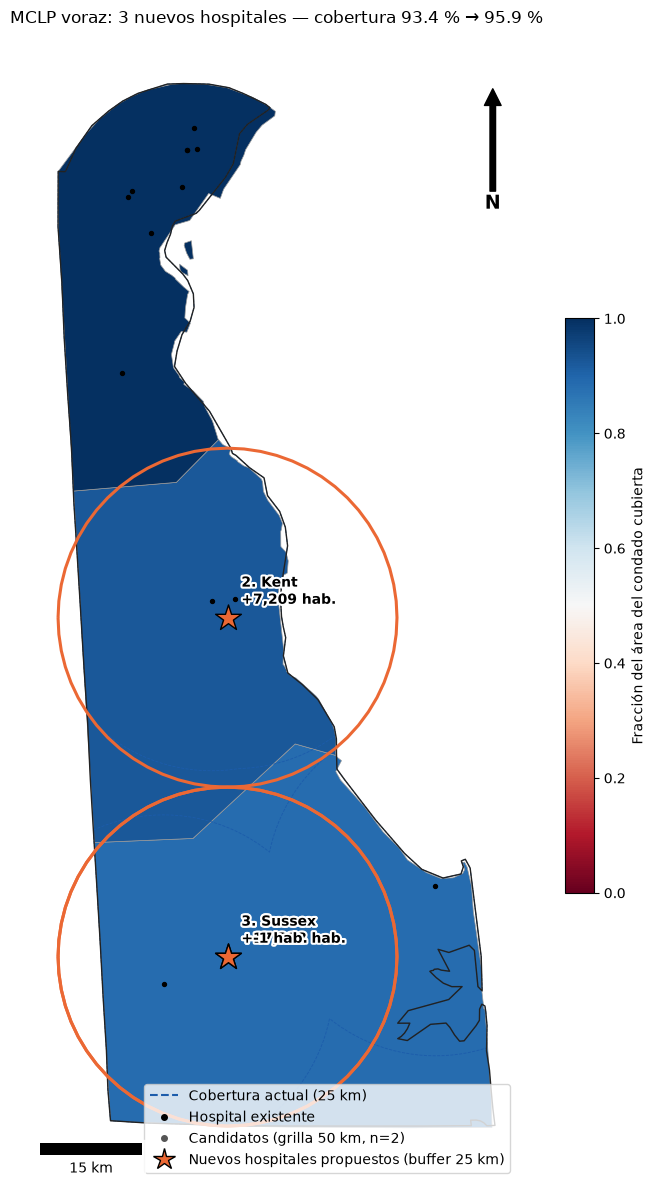

In [26]:
cty_p["frac_final"] = frac_covered(cov_state)
fig, ax = plt.subplots(figsize=(10, 12))
cty_p.plot(ax=ax, column="frac_final", cmap="RdBu", vmin=0, vmax=1, edgecolor="#9a9a9a", linewidth=0.5,
           legend=True, legend_kwds={"label": "Fracción del área del condado cubierta", "shrink": 0.5})
gpd.GeoSeries([cov25.intersection(state_poly)], crs=CRS_PROJ).boundary.plot(ax=ax, color="#1c5cab", lw=0.6, ls="--")
cand.plot(ax=ax, color="#555555", markersize=8, zorder=3)
gpd.GeoSeries(sel.geometry.buffer(S), crs=CRS_PROJ).boundary.plot(ax=ax, color=CAT[1], linewidth=2.2, zorder=4)
hosp_p.plot(ax=ax, color="black", markersize=8, zorder=4)
sel.plot(ax=ax, color=CAT[1], marker="*", markersize=380, edgecolor="black", zorder=5)
for _, r in sel.iterrows():
    ax.annotate(f"{r.iteracion}. {r.nombre}\n+{r.pob_adicional:,.0f} hab.", xy=(r.geometry.x, r.geometry.y),
                xytext=(10, 10), textcoords="offset points", fontsize=10, fontweight="bold",
                path_effects=[pe.withStroke(linewidth=3, foreground="white")], zorder=6)
state_p.boundary.plot(ax=ax, color="#222222", linewidth=1.0)
ax.legend(handles=[
    Line2D([], [], color="#1c5cab", ls="--", label=f"Cobertura actual ({R_MAP} km)"),
    Line2D([], [], marker="o", color="black", ls="", markersize=4, label="Hospital existente"),
    Line2D([], [], marker="o", color="#555555", ls="", markersize=4, label=f"Candidatos (grilla 50 km, n={len(cand)})"),
    Line2D([], [], marker="*", color=CAT[1], markeredgecolor="black", ls="", markersize=16,
           label=f"Nuevos hospitales propuestos (buffer {R_MAP} km)")], loc="lower right")
add_north_and_scale(ax)
ax.set_title(f"MCLP voraz: {P_NEW} nuevos hospitales — cobertura {base_pct:.1f} % → "
             f"{greedy_tbl.pct_cobertura_acumulada.iloc[-1]:.1f} %")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Task 3
## Task 3.1

### a. Cobertura por red vial e isocronas de 30 minutos

Se ordenan los condados por el índice de vulnerabilidad del Task 2.2 y se toma el hospital de mayor capacidad en
cada uno de los tres condados con mayor índice. Como Delaware tiene tres condados y todos poseen hospitales, esta
regla produce tres instalaciones distintas y mantiene la selección vinculada directamente con el índice.


In [27]:
import ast
import networkx as nx
import osmnx as ox
from pathlib import Path

vul_con_hosp = vul[vul["hospitales"] > 0].nlargest(3, "V")
rows = []
for _, county in vul_con_hosp.iterrows():
    candidates = hosp_p[hosp_p["fips_condado"] == county["fips"]]
    hospital = candidates.loc[[candidates["camas_total"].idxmax()]].copy()
    hospital["condado_vulnerable"] = county["nombre"]
    hospital["indice_vulnerabilidad"] = county["V"]
    rows.append(hospital)

hosp_iso = gpd.GeoDataFrame(pd.concat(rows, ignore_index=True), crs=CRS_PROJ)
assert len(hosp_iso) == 3 and hosp_iso["nombre"].nunique() == 3
hosp_iso[["condado_vulnerable", "nombre", "tipo", "camas_total", "indice_vulnerabilidad"]]


,condado_vulnerable,nombre,tipo,camas_total,indice_vulnerabilidad
0,Sussex,BEEBE MEDICAL CENTER,GENERAL ACUTE CARE,195.00,0.80
1,Kent,BAYHEALTH KENT GENERAL HOSPITAL,GENERAL ACUTE CARE,281.00,0.41
2,New Castle,CHRISTIANA CARE-WILMINGTON HOSPITAL,GENERAL ACUTE CARE,"1,097.00",0.16


Se usa el extracto OSM local de Delaware y OSMnx para construir una red dirigida exclusivamente vehicular. Primero
se conservan vías aptas para conducción y se excluyen accesos privados o prohibidos. Las longitudes se calculan
antes de simplificar el grafo, por lo que las aristas curvas conservan su longitud acumulada real.

OSMnx usa la velocidad publicada en OSM cuando existe e imputa valores faltantes según el tipo de vía. Para cada
arista $e$ se calcula

$$t_e = 3.6\,
rac{L_e}{v_e},$$

con $L_e$ en metros, $v_e$ en km/h y $t_e$ en segundos. Dijkstra obtiene los nodos alcanzables en un máximo de
1,800 segundos. Se procesa la red estatal completa, evitando que una frontera artificial recorte la isocrona.
El contorno se aproxima mediante una envolvente cóncava de los nodos alcanzables y un margen de 500 m que representa
el acceso desde la vía al entorno inmediato.


In [28]:
ox.settings.use_cache = True
ox.settings.log_console = False
GRAPH_DIR = Path("osm_graphs")
GRAPH_DIR.mkdir(exist_ok=True)
GRAPH_PATH = GRAPH_DIR / "delaware_drive.graphml"
OSM_PATH = Path("delaware.osm")
TRAVEL_TIME_S = 30 * 60

DRIVE_HIGHWAYS = {
    "motorway", "motorway_link", "trunk", "trunk_link", "primary", "primary_link",
    "secondary", "secondary_link", "tertiary", "tertiary_link", "unclassified",
    "residential", "living_street", "service", "road"
}
SPEEDS_KPH = {
    "motorway": 105, "motorway_link": 70, "trunk": 90, "trunk_link": 65,
    "primary": 80, "primary_link": 60, "secondary": 70, "secondary_link": 55,
    "tertiary": 60, "tertiary_link": 50, "unclassified": 50,
    "residential": 40, "living_street": 20, "service": 25, "road": 40,
}


def as_values(value):
    if isinstance(value, (list, tuple, set)):
        return {str(v) for v in value}
    if isinstance(value, str) and value.startswith("["):
        try:
            return {str(v) for v in ast.literal_eval(value)}
        except (ValueError, SyntaxError):
            pass
    return {str(value)} if value is not None else set()


def is_drive_edge(data):
    if not (as_values(data.get("highway")) & DRIVE_HIGHWAYS):
        return False
    blocked = {"no", "private"}
    for key in ("access", "vehicle", "motor_vehicle"):
        if as_values(data.get(key)) & blocked:
            return False
    return True


if GRAPH_PATH.exists():
    G_drive = ox.io.load_graphml(GRAPH_PATH)
else:
    if not OSM_PATH.exists():
        raise FileNotFoundError("Falta delaware.osm para construir la red vial de Delaware")
    G_raw = ox.graph_from_xml(OSM_PATH, simplify=False, retain_all=True)
    remove_edges = [(u, v, k) for u, v, k, data in G_raw.edges(keys=True, data=True)
                    if not is_drive_edge(data)]
    G_raw.remove_edges_from(remove_edges)
    G_raw.remove_nodes_from(list(nx.isolates(G_raw)))
    main_nodes = max(nx.weakly_connected_components(G_raw), key=len)
    G_drive = G_raw.subgraph(main_nodes).copy()
    G_drive = ox.simplification.simplify_graph(G_drive)
    ox.io.save_graphml(G_drive, GRAPH_PATH)

G_drive = ox.routing.add_edge_speeds(G_drive, hwy_speeds=SPEEDS_KPH, fallback=40)
G_drive = ox.routing.add_edge_travel_times(G_drive)

isochrones = []
reachable_edges = []
network_rows = []
hosp_ll = hosp_iso.to_crs("EPSG:4326")

for i, hospital in hosp_ll.iterrows():
    source = ox.distance.nearest_nodes(G_drive, hospital.geometry.x, hospital.geometry.y)
    travel = nx.single_source_dijkstra_path_length(
        G_drive, source, cutoff=TRAVEL_TIME_S, weight="travel_time"
    )
    G_iso = G_drive.subgraph(travel.keys()).copy()
    nodes_iso, edges_iso = ox.convert.graph_to_gdfs(G_iso)
    nodes_p = nodes_iso.to_crs(CRS_PROJ)
    edges_p = edges_iso.to_crs(CRS_PROJ)
    iso_geom = shapely.concave_hull(
        nodes_p.geometry.union_all(), ratio=0.25, allow_holes=False
    ).buffer(500).intersection(state_poly)

    isochrones.append(iso_geom)
    reachable_edges.append(edges_p)
    times_min = np.fromiter(travel.values(), dtype=float) / 60
    network_rows.append({
        "condado": hosp_iso.loc[i, "condado_vulnerable"],
        "hospital": hosp_iso.loc[i, "nombre"].title(),
        "nodos_alcanzables": len(nodes_iso),
        "tiempo_mediano_min": np.median(times_min),
        "tiempo_maximo_min": times_min.max(),
        "area_isocrona_km2": iso_geom.area / 1e6,
    })

network_tbl = pd.DataFrame(network_rows)
network_tbl.index += 1
network_tbl


,condado,hospital,nodos_alcanzables,tiempo_mediano_min,tiempo_maximo_min,area_isocrona_km2
1,Sussex,Beebe Medical Center,28995,19.27,30.00,"1,287.65"
2,Kent,Bayhealth Kent General Hospital,41620,14.92,30.00,"2,092.88"
3,New Castle,Christiana Care-Wilmington Hospital,61131,11.82,30.00,880.78


In [29]:
def estimated_population(geom):
    fractions = (cty_p.geometry.intersection(geom).area / cty_p.area).clip(0, 1)
    return float((cty_p["poblacion"] * fractions).sum())


comparison_rows = []
for i, hospital in hosp_iso.iterrows():
    buffer_geom = hospital.geometry.buffer(25_000).intersection(state_poly)
    pop_buffer = estimated_population(buffer_geom)
    pop_iso = estimated_population(isochrones[i])
    comparison_rows.append({
        "condado": hospital["condado_vulnerable"],
        "hospital": hospital["nombre"].title(),
        "pob_buffer_25km": pop_buffer,
        "pob_isocrona_30min": pop_iso,
        "diferencia_personas": pop_iso - pop_buffer,
        "diferencia_pct_buffer": 100 * (pop_iso - pop_buffer) / pop_buffer,
    })

buffer_union = unary_union(hosp_iso.geometry.buffer(25_000).values).intersection(state_poly)
iso_union = unary_union(isochrones).intersection(state_poly)
pop_buffer_union = estimated_population(buffer_union)
pop_iso_union = estimated_population(iso_union)
comparison_rows.append({
    "condado": "Conjunto",
    "hospital": "Tres hospitales",
    "pob_buffer_25km": pop_buffer_union,
    "pob_isocrona_30min": pop_iso_union,
    "diferencia_personas": pop_iso_union - pop_buffer_union,
    "diferencia_pct_buffer": 100 * (pop_iso_union - pop_buffer_union) / pop_buffer_union,
})

iso_comparison = pd.DataFrame(comparison_rows)
iso_comparison["pct_estado_buffer"] = 100 * iso_comparison["pob_buffer_25km"] / P_TOTAL
iso_comparison["pct_estado_isocrona"] = 100 * iso_comparison["pob_isocrona_30min"] / P_TOTAL
iso_comparison["diferencia_pp_estado"] = (
    iso_comparison["pct_estado_isocrona"] - iso_comparison["pct_estado_buffer"]
)
iso_comparison.index += 1
iso_comparison


,condado,hospital,pob_buffer_25km,pob_isocrona_30min,diferencia_personas,diferencia_pct_buffer,pct_estado_buffer,pct_estado_isocrona,diferencia_pp_estado
1,Sussex,Beebe Medical Center,"77,845.63","118,946.65","41,101.02",52.80,7.99,12.22,4.22
2,Kent,Bayhealth Kent General Hospital,"190,508.75","358,309.53","167,800.79",88.08,19.56,36.80,17.23
3,New Castle,Christiana Care-Wilmington Hospital,"297,482.02","418,988.36","121,506.34",40.84,30.55,43.03,12.48
4,Conjunto,Tres hospitales,"565,836.40","827,561.24","261,724.84",46.25,58.11,84.99,26.88


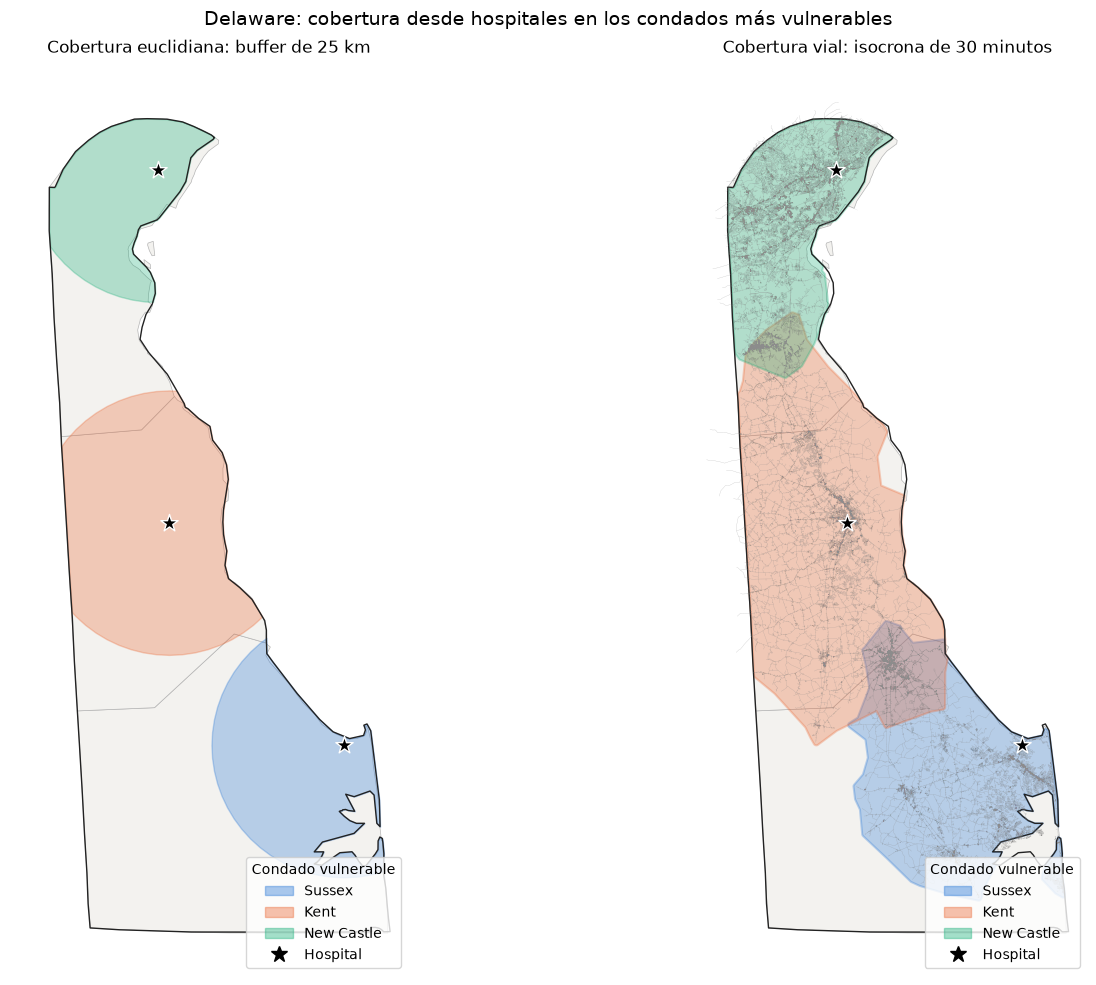

In [30]:
colors_iso = [CAT[0], CAT[1], CAT[2]]
fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharex=True, sharey=True)
for ax in axes:
    cty_p.plot(ax=ax, color="#f3f2ef", edgecolor="#b5b5b5", linewidth=0.5)
    state_p.boundary.plot(ax=ax, color="#222222", linewidth=1)
    hosp_iso.plot(ax=ax, color="black", marker="*", markersize=170, edgecolor="white", zorder=5)
    ax.set_axis_off()

for i, hospital in hosp_iso.iterrows():
    gpd.GeoSeries([hospital.geometry.buffer(25_000).intersection(state_poly)], crs=CRS_PROJ).plot(
        ax=axes[0], color=colors_iso[i], alpha=0.30, edgecolor=colors_iso[i]
    )
    reachable_edges[i].plot(ax=axes[1], color="#8c8c8c", linewidth=0.18, alpha=0.30)
    gpd.GeoSeries([isochrones[i]], crs=CRS_PROJ).plot(
        ax=axes[1], color=colors_iso[i], alpha=0.30, edgecolor=colors_iso[i], linewidth=1.5
    )

handles = [Patch(facecolor=colors_iso[i], edgecolor=colors_iso[i], alpha=0.4,
                 label=hosp_iso.loc[i, "condado_vulnerable"]) for i in range(len(hosp_iso))]
handles.append(Line2D([], [], marker="*", color="black", ls="", markersize=12, label="Hospital"))
axes[0].legend(handles=handles, loc="lower right", title="Condado vulnerable")
axes[1].legend(handles=handles, loc="lower right", title="Condado vulnerable")
axes[0].set_title("Cobertura euclidiana: buffer de 25 km")
axes[1].set_title("Cobertura vial: isocrona de 30 minutos")
fig.suptitle("Delaware: cobertura desde hospitales en los condados más vulnerables", fontsize=14)
plt.tight_layout()
plt.show()


### b. Sesgo del buffer circular en Delaware

Sea $d_E(x,h)$ la distancia euclidiana y $T_R(x,h)$ el tiempo mínimo por la red vial desde un punto $x$ hasta el
hospital $h$. El buffer considera cubierto a $x$ cuando $d_E(x,h)\leq25$ km; la isocrona lo considera cubierto
cuando $T_R(x,h)\leq30$ min. Las métricas solo serían equivalentes si la velocidad efectiva fuera uniforme y la
red permitiera desplazarse en cualquier dirección sin barreras.

El buffer **sobreestima** el acceso en sectores donde la distancia recta es corta pero la ruta debe desviarse.
En Delaware esto ocurre junto a la bahía y el río Delaware, en las bahías y canales costeros de Sussex y alrededor
del Chesapeake and Delaware Canal, porque los cruces se concentran en carreteras y puentes concretos. El círculo
también se extiende sobre agua y sobre zonas rurales con pocas conexiones transversales, aunque esos espacios no
ofrezcan un recorrido directo de 30 minutos.

El buffer **subestima** el acceso a lo largo de corredores rápidos. I-95 e I-295 en New Castle y DE-1, US-13 y
US-113 hacia Kent y Sussex permiten recorrer más de 25 km en media hora. Por eso la isocrona se alarga siguiendo
esos ejes y se contrae entre ellos. Su forma anisotrópica refleja la conectividad real de la red estatal.

Los tiempos representan circulación sin congestión dinámica. No incorporan tráfico por hora, cierres, clima,
tiempo de despacho ni el trayecto desde una vivienda hasta la vía, por lo que no deben interpretarse como tiempos
garantizados de emergencia.

### c. Implicaciones para política pública

1. **Ubicación de hospitales, clínicas o bases de ambulancias.** Un buffer puede dar por cubiertas comunidades
   rurales de Sussex o sectores separados por agua y pocos cruces. Las isocronas conservan como prioritarias las
   comunidades que realmente superan 30 minutos y evitan duplicar infraestructura junto a corredores rápidos.
2. **Áreas de referencia y despacho de ambulancias.** El hospital más cercano en línea recta no siempre ofrece el
   menor tiempo vial. Las isocronas pueden cambiar qué hospital recibe una comunidad, la ubicación de ambulancias
   y los acuerdos de traslado entre Kent, Sussex y New Castle.
3. **Asignación de fondos y metas de cobertura.** Financiar según buffers puede ocultar déficits en la red rural o
   exagerarlos cerca de I-95 y DE-1. Las isocronas permiten dirigir recursos a mejoras hospitalarias, transporte
   sanitario o conexiones viales según la brecha temporal observada.


## Task 3.3

### a. Análisis de sensibilidad del índice de vulnerabilidad

Se comparan cuatro configuraciones de pesos. Además del escenario base del Task 2.2, se incluye una distribución
equitativa, una que prioriza la distancia y otra que prioriza la falta de camas. Para cada escenario se recalcula
el índice, se obtiene el ranking y se compara con el escenario base mediante la correlación de Spearman y el cambio
promedio de posición.


In [31]:
WEIGHT_SCENARIOS = {
    "Base": {"C1": 0.45, "C2": 0.35, "C3": 0.20},
    "Equitativo": {"C1": 1 / 3, "C2": 1 / 3, "C3": 1 / 3},
    "Prioriza distancia": {"C1": 0.60, "C2": 0.20, "C3": 0.20},
    "Prioriza capacidad": {"C1": 0.25, "C2": 0.55, "C3": 0.20},
}

scores = pd.DataFrame(index=vul["nombre"])
ranks = pd.DataFrame(index=vul["nombre"])
for scenario, weights in WEIGHT_SCENARIOS.items():
    score = sum(weight * vul.set_index("nombre")[component]
                for component, weight in weights.items())
    scores[scenario] = score
    ranks[scenario] = score.rank(ascending=False, method="min").astype(int)

ranks = ranks.sort_values("Base")
scores = scores.loc[ranks.index]
base_rank = ranks["Base"]
top_n = min(10, len(ranks))
base_top = set(base_rank.nsmallest(top_n).index)
stability_rows = []
for scenario in ranks.columns:
    current_top = set(ranks[scenario].nsmallest(top_n).index)
    rho = stats.spearmanr(base_rank, ranks[scenario]).statistic
    stability_rows.append({
        "escenario": scenario,
        "correlacion_spearman": rho,
        "cambio_medio_posicion": (ranks[scenario] - base_rank).abs().mean(),
        f"coincidencia_top_{top_n}": len(base_top & current_top) / top_n,
    })

stability_tbl = pd.DataFrame(stability_rows).set_index("escenario")
display(scores.round(3))
display(ranks)
stability_tbl.round(3)


,Base,Equitativo,Prioriza distancia,Prioriza capacidad
nombre,,,,
Sussex,0.80,0.67,0.80,0.80
Kent,0.41,0.53,0.36,0.48
New Castle,0.16,0.27,0.16,0.16


,Base,Equitativo,Prioriza distancia,Prioriza capacidad
nombre,,,,
Sussex,1,1,1,1
Kent,2,2,2,2
New Castle,3,3,3,3


,correlacion_spearman,cambio_medio_posicion,coincidencia_top_3
escenario,,,
Base,1.00,0.00,1.00
Equitativo,1.00,0.00,1.00
Prioriza distancia,1.00,0.00,1.00
Prioriza capacidad,1.00,0.00,1.00


El orden de los tres condados se mantiene en todas las configuraciones: Sussex ocupa el primer lugar, Kent el
segundo y New Castle el tercero. Esto indica que, dentro de Delaware, la conclusión general no depende de una sola
elección de pesos. Sin embargo, la estabilidad debe interpretarse con cautela: el estado solo tiene tres condados,
por lo que el “top 10” solicitado se reduce necesariamente a los tres disponibles. El análisis respalda la prioridad
relativa de Sussex, pero no demuestra que los pesos funcionarían igual en un territorio con más unidades y mayor
diversidad.

### b. Caso adverso para el algoritmo voraz

El algoritmo voraz puede alejarse del óptimo cuando un candidato central cubre partes de varias concentraciones de
población y obtiene la mayor ganancia inicial, pero se traslapa mucho con las mejores opciones posteriores. En el
ejemplo conceptual siguiente, el punto central cubre 12 personas y es elegido primero. Después, un punto lateral
solo agrega 4, para un total de 16. La solución óptima elige los dos puntos laterales, que cubren grupos separados
de 10 personas cada uno y alcanzan 20.


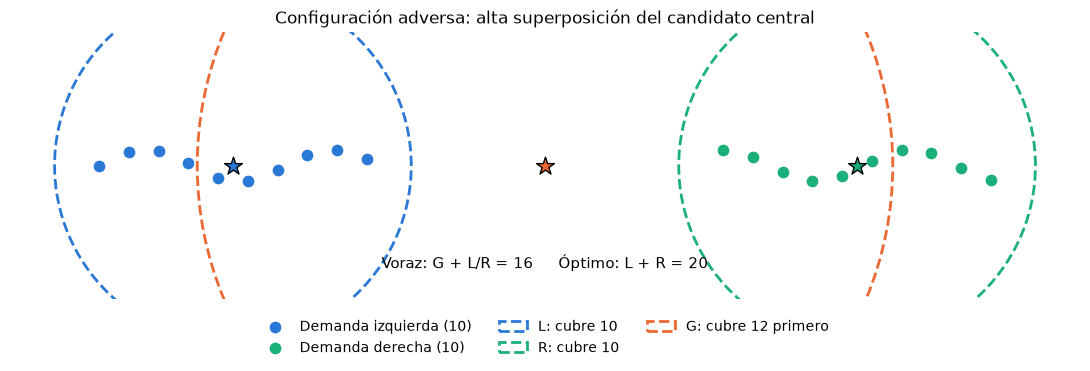

In [32]:
from matplotlib.patches import Circle

left_x = np.linspace(0, 3, 10)
right_x = np.linspace(7, 10, 10)
left_y = 0.18 * np.sin(np.arange(10))
right_y = 0.18 * np.cos(np.arange(10))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(left_x, left_y, color=CAT[0], s=55, label="Demanda izquierda (10)")
ax.scatter(right_x, right_y, color=CAT[2], s=55, label="Demanda derecha (10)")

for center, radius, color, label in [
    ((1.5, 0), 2.0, CAT[0], "L: cubre 10"),
    ((8.5, 0), 2.0, CAT[2], "R: cubre 10"),
    ((5.0, 0), 3.9, CAT[1], "G: cubre 12 primero"),
]:
    ax.add_patch(Circle(center, radius, fill=False, color=color, linewidth=2,
                        linestyle="--", label=label))
    ax.scatter(*center, marker="*", s=180, color=color, edgecolor="black", zorder=4)

ax.text(5, -1.15, "Voraz: G + L/R = 16     Óptimo: L + R = 20", ha="center", fontsize=11)
ax.set(xlim=(-1, 11), ylim=(-1.5, 1.5), title="Configuración adversa: alta superposición del candidato central")
ax.set_aspect("equal")
ax.set_axis_off()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.03), ncol=3, frameon=False)
plt.tight_layout()
plt.show()


La pérdida aparece porque el método solo evalúa la mejor ganancia del momento y no anticipa la combinación de los
puntos restantes. Este patrón puede ocurrir cuando hay dos núcleos de población separados y un candidato intermedio
cubre las zonas interiores de ambos. Para reducir el riesgo se podría comparar la solución voraz con varias
inicializaciones, aplicar búsqueda local o resolver el MCLP exacto con programación entera cuando el número de
candidatos lo permita.

### c. Limitaciones que deben comunicarse al departamento de salud

| Limitación | Consecuencia para la decisión | Dato o mejora necesaria |
|---|---|---|
| La población se distribuye uniformemente dentro de cada condado. | Puede asignar personas a zonas rurales o cuerpos de agua donde realmente no viven y alterar la cobertura estimada. | Usar población por bloque o sector censal, o una cuadrícula de población de alta resolución. |
| Las isocronas usan velocidades estimadas y no incluyen tráfico, clima, cierres ni tiempos de despacho. | Treinta minutos de flujo libre pueden ser más largos durante una emergencia real. | Incorporar velocidades observadas por horario, registros de ambulancias y escenarios de congestión. |
| Las camas y la ocupación no describen todos los servicios disponibles. | Un hospital cercano puede no tener emergencia, especialidad, personal o camas libres para atender el caso. | Incorporar capacidad de urgencias, personal, especialidades, disponibilidad temporal y flujos hacia hospitales de estados vecinos. |

Estas limitaciones no anulan el análisis, pero indican que sus resultados sirven para identificar zonas prioritarias
y comparar escenarios, no para decidir por sí solos la ubicación definitiva de una instalación o una ruta de
emergencia.
